# General Overview

Daily measurements of solar and geomagnetic activity going back to 1957, sourced from NOAA's Space Weather Prediction Center (SWPC) via CelesTrak.

Four key indices are tracked:
1. Kp: Planetary-scale disturbances in Earth's magnetic field, on a 0–9 scale
2. Ap: A daily average version of Kp, expressed in nanotesla
3. F10.7: Daily solar radio flux, a proxy for the Sun's UV output
4. Sunspot Number: Count of sunspots on the Sun's surface; the standard measure of the solar cycle

Together, these four numbers describe the "space weather" environment around Earth on any given day.

Kp and Ap capture how disturbed Earth's magnetic field is. High values indicate a geomagnetic storm (these produce auroras and can disrupt satellites, GPS, and power grids). 

NOAA's G1–G5 storm severity scale is derived directly from Kp.

F10.7 tracks how active the sun is. More solar activity means more UV radiation heating the upper atmosphere, which makes it denser. This creates more drag on low-orbit satellites, causing them to slow down and re-enter faster than expected.

Important Counts:
- 25,089 observed days (1957-10-01 to 2026-06-09)
- 613 geomagnetic storm days (Ap >= 50)

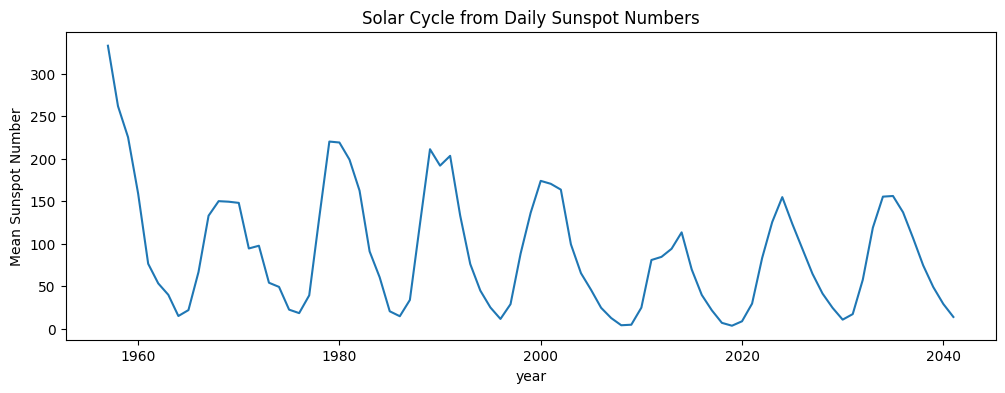

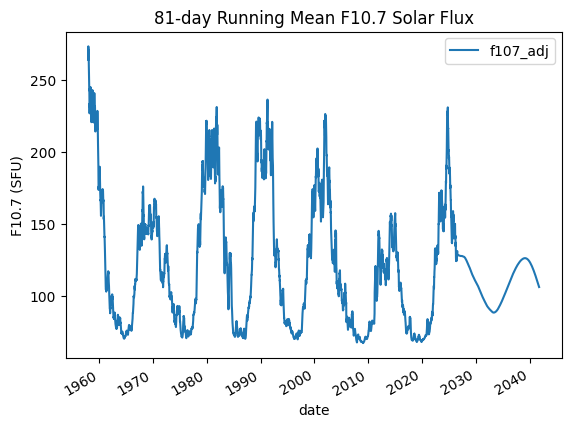

In [5]:
from datasets import load_dataset

ds = load_dataset("juliensimon/space-weather-indices", split="train")
df = ds.to_pandas()

# Only observed data (exclude predictions)
observed = df[df["data_type"] == "observed"]

# Geomagnetic storms
storms = df[df["is_storm"] == True].sort_values("ap_avg", ascending=False)

# Solar cycle visualization
import matplotlib.pyplot as plt
df["year"] = df["date"].dt.year
yearly_ssn = df.groupby("year")["sunspot_number"].mean()
yearly_ssn.plot(figsize=(12, 4))
plt.ylabel("Mean Sunspot Number")
plt.title("Solar Cycle from Daily Sunspot Numbers")
plt.show()

# F10.7 flux trend (drives atmospheric drag)
df.set_index("date")[["f107_adj"]].rolling(81).mean().plot()
plt.ylabel("F10.7 (SFU)")
plt.title("81-day Running Mean F10.7 Solar Flux")
plt.show()


Columns Information
- Date
- Bartels (can probably ignore - solar alignment convention usually only used for solar physics work)
- All the Kp values (recorded in 3 hour intervals) + kp_sum
- All the Ap values (recorded in 3 hour intervals) + ap_avg
- cp / c9 : older geomagnetic indices superseded by Kp/Ap for most purposes
- Sunspot number
- f107_obs_center81 / f107_obs_last81 - smoothed F10.7, which is what atmospheric models actually want (raw daily F10.7 is noisy)

Note for f107:
_obs — the raw measurement as recorded at the Penticton observatory
_adj — corrected to what the flux would be if Earth were exactly 1 AU from the Sun, removing the seasonal distance effect

So, use obs over adj. 

## Data Quality

In [14]:
import pandas as pd

null_counts = observed.isnull().sum()
total_nulls = null_counts.sum()

print("NULL COUNTS: ")
print(null_counts)
print(f"Total null values across table: {total_nulls:,}")
print(f"Total rows: {len(observed):,}\n")


NULL COUNTS: 
date                   0
bartels_rotation       0
bartels_day            0
kp_0000                0
kp_0300                0
kp_0600                0
kp_0900                0
kp_1200                0
kp_1500                0
kp_1800                0
kp_2100                0
kp_sum                 0
ap_0000                0
ap_0300                0
ap_0600                0
ap_0900                0
ap_1200                0
ap_1500                0
ap_1800                0
ap_2100                0
ap_avg                 0
cp                     0
c9                     0
sunspot_number         0
f107_obs               0
f107_adj               0
f107_data_type         0
f107_obs_center81      0
f107_obs_last81        0
f107_adj_center81      0
f107_adj_last81        0
is_storm               0
storm_level          164
data_type              0
dtype: int64
Total null values across table: 164
Total rows: 25,089



## Distributions

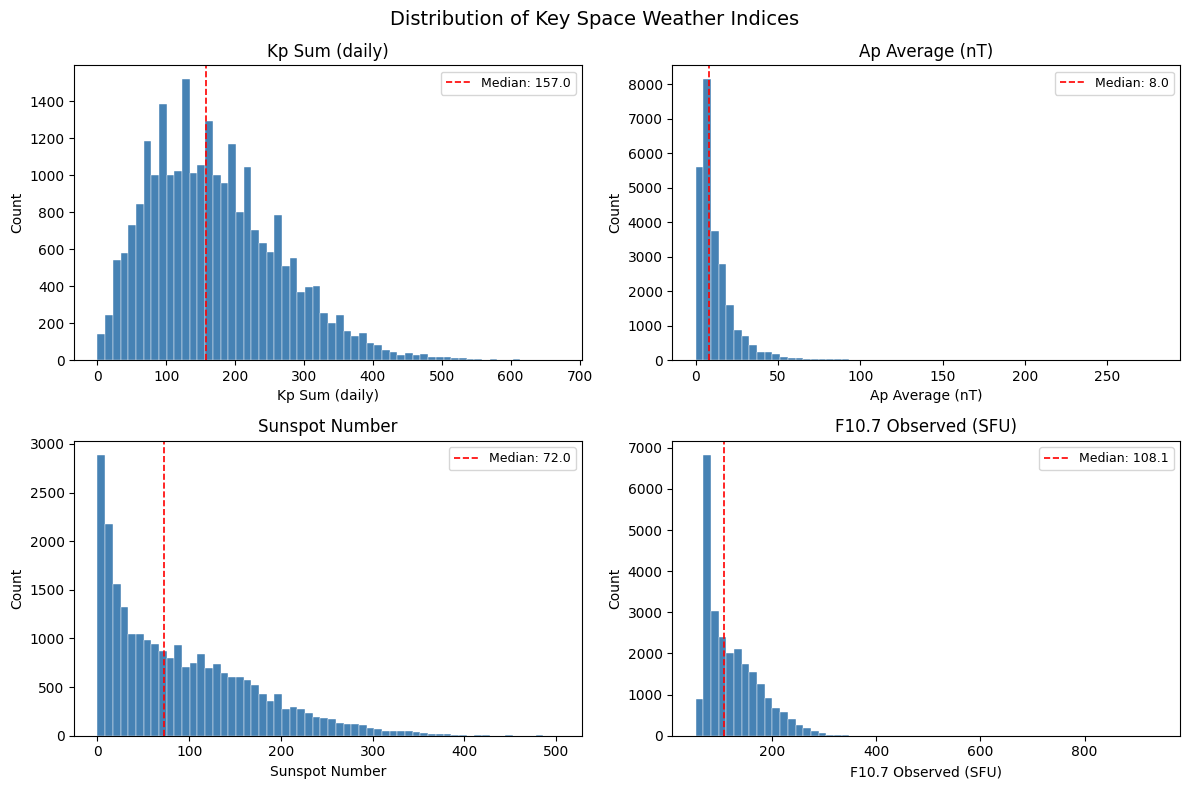

In [7]:
import matplotlib.pyplot as plt

cols   = ['kp_sum', 'ap_avg', 'sunspot_number', 'f107_obs']
labels = ['Kp Sum (daily)', 'Ap Average (nT)', 'Sunspot Number', 'F10.7 Observed (SFU)']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Distribution of Key Space Weather Indices', fontsize=14)

for ax, col, label in zip(axes.flatten(), cols, labels):
    data = observed[col].dropna()
    ax.hist(data, bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
    ax.axvline(data.median(), color='red', linestyle='--', linewidth=1.2,
               label=f'Median: {data.median():.1f}')
    ax.set_title(label)
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()